In [1]:
import math
import time

import bs4
import pandas as pd
import requests
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import gnews
import yfinance as yf
from gnews import GNews
from lxml.html.diff import href_token
import bs4 as bs
import json
import csv
import nltk
from mpmath.libmp import round_up
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
from transformers import AutoTokenizer,AutoModelForSequenceClassification,pipeline
from scipy.special import softmax

In [2]:
news=GNews(start_date=(2019,11,4), end_date=(2024,11,2),max_results=1000)
ns=news.get_news("Microsoft")

C:\Users\Asus\anaconda3\Lib\site-packages\gnews\gnews.py:218: UserWarning: Only searches using get_news support date ranges. Start and end dates will be ignored.
  return self._get_news_more_than_100(key)


In [1]:
news_df=pd.DataFrame(data=ns)
news_df.head()

NameError: name 'pd' is not defined

In [4]:
news_df.shape

(1000, 5)

In [40]:
temp=news_df
temp["full_text"] = (temp["title"].fillna("") + "" +temp["description"].fillna(""))

In [41]:
temp.head()

,title,description,published date,url,publisher,full_text
0,Microsoft Bans Term ‘Microslop’ From Official ...,Microsoft Bans Term ‘Microslop’ From Official ...,"Mon, 02 Mar 2026 19:40:56 GMT",https://news.google.com/rss/articles/CBMikwFBV...,"{'href': 'https://gizmodo.com', 'title': 'Gizm...",Microsoft Bans Term ‘Microslop’ From Official ...
1,"Microsoft says stop calling it Microslop, or y...","Microsoft says stop calling it Microslop, or y...","Mon, 02 Mar 2026 15:35:00 GMT",https://news.google.com/rss/articles/CBMiowFBV...,"{'href': 'https://www.pcworld.com', 'title': '...","Microsoft says stop calling it Microslop, or y..."
2,Why the Microsoft 365 Copilot bug matters for ...,Why the Microsoft 365 Copilot bug matters for ...,"Mon, 02 Mar 2026 15:37:32 GMT",https://news.google.com/rss/articles/CBMihwFBV...,"{'href': 'https://www.foxnews.com', 'title': '...",Why the Microsoft 365 Copilot bug matters for ...
3,Microsoft ends data center non-disclosure agre...,Microsoft ends data center non-disclosure agre...,"Tue, 03 Mar 2026 19:22:00 GMT",https://news.google.com/rss/articles/CBMi6wFBV...,"{'href': 'https://www.detroitnews.com', 'title...",Microsoft ends data center non-disclosure agre...
4,Microsoft’s big developer conference returns t...,Microsoft’s big developer conference returns t...,"Tue, 03 Mar 2026 17:00:00 GMT",https://news.google.com/rss/articles/CBMiggFBV...,"{'href': 'https://www.theverge.com', 'title': ...",Microsoft’s big developer conference returns t...


In [48]:
temp.iloc[2,1]

'Why the Microsoft 365 Copilot bug matters for data security  Fox News'

In [8]:
news_df.to_csv(r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\MSFT_news.csv")

In [2]:
subreddit=["https://www.reddit.com/r/wallstreetbets/","https://www.reddit.com/r/stocks/"]

In [3]:
'''def scrape_reddit(subreddit:str,total_posts:int):

    all_data=[]         #main list
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}     #framework

    for index,url in enumerate(subreddit):
        sr_name=url.split("/")[-2]      #names of subreddit
        after=None
        posts=[]
        print(sr_name)

        while len(all_data) < total_posts:

            params = {"limit": 100}
            if after:
                params["after"] = after

            try:
                response=requests.get(f"https://www.reddit.com/r/{sr_name}/.json",headers=headers,timeout=15,params=params)
                res_json=response.json()
                print(res_json)
                data = res_json["data"]["children"]
                response.raise_for_status()


                for post in data:
                    p = post["data"]
                    posts.append({"subreddit": sr_name,"title": p["title"],"url": "https://reddit.com" + p["permalink"],"score": p["score"],"num_comments": p["num_comments"],"created": p["created_utc"]})

                after = res_json["data"]["after"]

                if after is None:
                    break
                time.sleep(1)

                all_data.append(posts)


            except Exception as e:
                print(e)

    return all_data

def save_scraped_data(data, filename_json, filename_csv):
    if not data:
        print(f'No data')
        return


    try:
        with open(filename_json, "w", encoding="utf-8") as file:
            json.dump(data, file, indent=2, ensure_ascii=True)
        print(f'Topics saved: {filename_json}')
    except Exception as e:
        print("ERROR:",e)



    try:
        with open(filename_csv, 'w', newline='', encoding='utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(['Subreddit', 'Type', 'Title', 'URL'])

            for subreddit_data in data:
                subreddit = subreddit_data['name']

                for topic in subreddit_data.get('topics', []):
                    writer.writerow([subreddit, topic['type'], topic['title'], ''])

                for discussion in subreddit_data.get('discussions', []):
                    writer.writerow([subreddit, discussion['type'], discussion['title'], discussion['url']])

            print(f'All topics saved to files!')
    except Exception as e:
        print("Error:",e)

a=scrape_reddit(subreddit,5)
save_scraped_data(a,"smth.json","smth.csv")
a'''

In [22]:
'''def scrape_reddit(subreddit):
    all_data=[]
    for index,url in enumerate(subreddit):
        headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}
        sr_name=url.split("/")[-2]
        print(sr_name)

        try:
            response=requests.get(url,headers=headers,timeout=15)
            response.raise_for_status()

            soup=bs4.BeautifulSoup(response.content,"html.parser")

            subreddit_data={"name":sr_name,"url":url,"title":soup.title.string if soup.title.string else "No Title"}


            topics=[]

            for heading in soup.find_all(['h1','h2','h3','h4']):
                text=heading.get_text(strip=True)

                if text and len(text)>3:
                    if any(keyword in text.lower() for keyword in ['rise','oil','bullish','stocks','bonds','tax','chips','luxury']):
                        topics.append({"title":text,"subreddit":sr_name,"type":"topic"})
            discussions=[]
            seen_url=set()

            for link in soup.find_all('a',href=True):
                text=link.get_text(strip=True)
                href=link['href']
                if text and len(text)>1 and ('/comments/' in href) and (href not in seen_url):
                    seen_url.add(href)
                    discussions.append({"title":text,"url":href,"type":"discussions"})

            subreddit_data["topic"]=topics
            subreddit_data["discussions"]=discussions


            all_data.append(subreddit_data)
            time.sleep(2)

        except Exception as e:
            print(e)

    return all_data

def save_scraped_data(data, filename_json, filename_csv):
    if not data:
        print(f'No data')
        return


    try:
        with open(filename_json, "w", encoding="utf-8") as file:
            json.dump(data, file, indent=2, ensure_ascii=True)
        print(f'Topics saved: {filename_json}')
    except Exception as e:
        print("ERROR:",e)



    try:
        with open(filename_csv, 'w', newline='', encoding='utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(['Subreddit', 'Type', 'Title', 'URL'])

            for subreddit_data in data:
                subreddit = subreddit_data['name']

                for topic in subreddit_data.get('topics', []):
                    writer.writerow([subreddit, topic['type'], topic['title'], ''])

                for discussion in subreddit_data.get('discussions', []):
                    writer.writerow([subreddit, discussion['type'], discussion['title'], discussion['url']])

            print(f'All topics saved to files!')
    except Exception as e:
        print("Error:",e)
a=scrape_reddit(subreddit)
save_scraped_data(a,"smth.json","smth.csv")
a
'''

In [3]:
def scrape_reddit(subreddit: list, total_posts: int):
    all_data = []  #main list
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"}  #framework

    for index, url in enumerate(subreddit):
        sr_name = url.split("/")[-2]  #names of subreddit
        after = None
        posts = []
        print(sr_name)

        while len(posts) < total_posts:

                params = {"limit": total_posts if total_posts<100 else 100}
                #to check the loop may be taking 50 posts then is checking which is the stuff we want etc
                if after:
                    params["after"] = after

                try:
                    response = requests.get(f"https://www.reddit.com/r/{sr_name}/.json", headers=headers, timeout=15,
                                            params=params)
                    res_json = response.json()
                    data = res_json["data"]["children"]
                    response.raise_for_status()

                    for post in data:
                        p = post["data"]

                        comment_url = "https://reddit.com" + p["permalink"] + ".json"

                        comment_response = requests.get(comment_url, headers=headers)
                        comment_json = comment_response.json()
                        comments = []

                        for c in comment_json[1]["data"]["children"]:
                            time.sleep(0.5)
                            if c["kind"] == "t1":   # t1 = comment
                                comments.append(c["data"]["body"])

                        posts.append({"subreddit": sr_name,"title": p["title"],"url": "https://reddit.com" + p["permalink"],"score": p["score"],"num_comments": p["num_comments"],"comments": comments})
                        print(len(posts))

                    after = res_json["data"]["after"]

                    if after is None:
                        break
                    time.sleep(1)

                    all_data.extend(posts)


                except Exception as e:
                    print(e)

    return all_data


def save_scraped_data(data, filename_json, filename_csv):
    if not data:
        print(f'No data')
        return

    try:
        with open(filename_json, "w", encoding="utf-8") as file:
            json.dump(data, file, indent=2, ensure_ascii=True)
        print(f'Topics saved: {filename_json}')
    except Exception as e:
        print("ERROR:", e)

    try:
        with open(filename_csv, 'w', newline='', encoding='utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(['Subreddit', 'Type', 'Title', 'URL'])

            for subreddit_data in data:
                subreddit = subreddit_data['name']

                for topic in subreddit_data.get('topics', []):
                    writer.writerow([subreddit, topic['type'], topic['title'], ''])

                for discussion in subreddit_data.get('discussions', []):
                    writer.writerow([subreddit, discussion['type'], discussion['title'], discussion['url']])

            print(f'All topics saved to files!')
    except Exception as e:
        print("Error:", e)

In [4]:
a=scrape_reddit(subreddit,50)

50


In [5]:
a

[{'subreddit': 'wallstreetbets',
  'title': 'Weekly Earnings Thread 3/9 - 3/13',
  'url': 'https://reddit.com/r/wallstreetbets/comments/1rmix7j/weekly_earnings_thread_39_313/',
  'score': 51,
  'num_comments': 203,
  'comments': ['Dangerous week to be playing earnings. Big moves up and down based on macro events ',
   'What earnings are people playing this week? ',
   'ORCL gonna be flat',
   "ADBE puts around $265\n\nIt's basically printing money",
   'Does HPE pop Monday? I hear they have an AI server play similar to DELL',
   "If you're not in Oracle puts as soon as the market opens you're actually just allergic to money.\n\nThe scam ends this week.",
   'so what are we doing with this info just asking im new here.',
   'short dicks',
   "Isn't Unusual Machines Don Jr's latest means to enrich that family off our taxpayer dollars? ",
   "I was super bullish on Oracle earnings. Couldn’t find a single reason the stock won't moon.\nThen Jim Cramer said he’s bullish too…\nNow I can’t fin

In [6]:
a_df=pd.DataFrame(a)
a_df.iloc[1,5]

["Feel like crud.  Couldn't fall asleep last night.  I know it's a temporary thing but so many people are struggling &amp; can't see past it.",
 'Soooo how epic of a nut squeeze is gonna be on HIMs come Monday morning? Will we see $30 this week? Maybe 40?',
 'I’ll start sweating when we break into the 6600s ',
 'After the crash there will be a historical bull run',
 'do you know how funny it would be if the market tanked 10% then we gut social security 🌈 ',
 'Black Tuesday.',
 'Guaranteed this dip will be bought this week and all the regard bears will have FOMO',
 'ukraine/russia\n\nafghanistan/pakistan\n\nusa/israel/iran\n\nhow many more do we need to add to make it official ww3',
 'shits dumb ',
 'why are we still changing clocks ',
 'I feel like the market will free fall once it realizes high energy, inflation, ww3 is here to stay and not just temporary.',
 'I cannot remember the last time I was long only coming out of a weekend. Feels weird and sorta slimey.\n\nErrrrr....go stocks.

In [7]:
a_df.to_csv(r"C:\Users\Asus\PycharmProjects\test_2\smth.csv")


In [ ]:
#soup.prettify makes html look like normal

#soup.find('<h1,h2,h5,div>') gives that tag line it gives first occurence of h5 soup.find_all('<h5>') gives all occurences
#tags=soup.find_all('<h5>')
#for i in tags:
#   i.text gives text values

#fs=soup.find_all('div',class_='card') {class_ here _ is important as class is a keyword in python}
#for i in fs:
#   i.<'h5','h1'> will give h5 tages or h1 tags
#   i.h5.text gives text
#   i.a

In [26]:
#nltk.download('vader_lexicon')
#nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

True

In [2]:
vad=SentimentIntensityAnalyzer()

In [3]:
s='Hi I am very not happy'
token=nltk.word_tokenize(s)

In [32]:
nltk.pos_tag(token)

[('Hi', 'NNP'),
 ('I', 'PRP'),
 ('am', 'VBP'),
 ('very', 'RB'),
 ('not', 'RB'),
 ('happy', 'JJ')]

In [4]:
path=r"C:\Users\Asus\PycharmProjects\test_2\smth.csv"

In [5]:
df=pd.read_csv(path)

In [6]:
df.iloc[:,6]

0     ['Dangerous week to be playing earnings. Big m...
1     ["Feel like crud.  Couldn't fall asleep last n...
2     ['\n**User Report**| | | |\n:--|:--|:--|:--\n*...
3     ['\n**User Report**| | | |\n:--|:--|:--|:--\n*...
4     ['\n**User Report**| | | |\n:--|:--|:--|:--\n*...
                            ...                        
95    ['Serious exaggeration. ', 'Modern gaming revo...
96    ['My average is 94 😭', 'For TEAM, my target ra...
97    ['Loaded the fuck up average 2.30, not selling...
98                                                   []
99    ["Look at how valuable Warner's IP turned out ...
Name: comments, Length: 100, dtype: object

In [7]:
df.iloc[:,6][1]

'["Feel like crud.  Couldn\'t fall asleep last night.  I know it\'s a temporary thing but so many people are struggling &amp; can\'t see past it.", \'Soooo how epic of a nut squeeze is gonna be on HIMs come Monday morning? Will we see $30 this week? Maybe 40?\', \'I’ll start sweating when we break into the 6600s \', \'After the crash there will be a historical bull run\', \'do you know how funny it would be if the market tanked 10% then we gut social security 🌈 \', \'Black Tuesday.\', \'Guaranteed this dip will be bought this week and all the regard bears will have FOMO\', \'ukraine/russia\\n\\nafghanistan/pakistan\\n\\nusa/israel/iran\\n\\nhow many more do we need to add to make it official ww3\', \'shits dumb \', \'why are we still changing clocks \', \'I feel like the market will free fall once it realizes high energy, inflation, ww3 is here to stay and not just temporary.\', \'I cannot remember the last time I was long only coming out of a weekend. Feels weird and sorta slimey.\\n\

In [8]:
t=[]
for tokens in df.iloc[:,6]:
        t.extend(nltk.word_tokenize(tokens))

In [9]:
print(len(t),t)

94012 ['[', "'Dangerous", 'week', 'to', 'be', 'playing', 'earnings', '.', 'Big', 'moves', 'up', 'and', 'down', 'based', 'on', 'macro', 'events', "'", ',', "'What", 'earnings', 'are', 'people', 'playing', 'this', 'week', '?', "'", ',', "'ORCL", 'gon', 'na', 'be', 'flat', "'", ',', '``', 'ADBE', 'puts', 'around', '$', '265\\n\\nIt', "'s", 'basically', 'printing', 'money', "''", ',', "'Does", 'HPE', 'pop', 'Monday', '?', 'I', 'hear', 'they', 'have', 'an', 'AI', 'server', 'play', 'similar', 'to', 'DELL', "'", ',', '``', 'If', 'you', "'re", 'not', 'in', 'Oracle', 'puts', 'as', 'soon', 'as', 'the', 'market', 'opens', 'you', "'re", 'actually', 'just', 'allergic', 'to', 'money.\\n\\nThe', 'scam', 'ends', 'this', 'week', '.', '``', ',', "'so", 'what', 'are', 'we', 'doing', 'with', 'this', 'info', 'just', 'asking', 'im', 'new', 'here', '.', "'", ',', "'short", 'dicks', "'", ',', '``', 'Is', "n't", 'Unusual', 'Machines', 'Don', 'Jr', "'s", 'latest', 'means', 'to', 'enrich', 'that', 'family', 'off

In [10]:
tags=nltk.pos_tag(t)
tags

[('[', 'RB'),
 ("'Dangerous", 'JJ'),
 ('week', 'NN'),
 ('to', 'TO'),
 ('be', 'VB'),
 ('playing', 'JJ'),
 ('earnings', 'NNS'),
 ('.', '.'),
 ('Big', 'NNP'),
 ('moves', 'VBZ'),
 ('up', 'RB'),
 ('and', 'CC'),
 ('down', 'RB'),
 ('based', 'VBN'),
 ('on', 'IN'),
 ('macro', 'JJ'),
 ('events', 'NNS'),
 ("'", 'POS'),
 (',', ','),
 ("'What", 'IN'),
 ('earnings', 'NNS'),
 ('are', 'VBP'),
 ('people', 'NNS'),
 ('playing', 'VBG'),
 ('this', 'DT'),
 ('week', 'NN'),
 ('?', '.'),
 ("'", "''"),
 (',', ','),
 ("'ORCL", "''"),
 ('gon', 'NN'),
 ('na', 'TO'),
 ('be', 'VB'),
 ('flat', 'JJ'),
 ("'", "''"),
 (',', ','),
 ('``', '``'),
 ('ADBE', 'NNP'),
 ('puts', 'VBZ'),
 ('around', 'IN'),
 ('$', '$'),
 ('265\\n\\nIt', 'CD'),
 ("'s", 'POS'),
 ('basically', 'RB'),
 ('printing', 'VBG'),
 ('money', 'NN'),
 ("''", "''"),
 (',', ','),
 ("'Does", 'VBZ'),
 ('HPE', 'NNP'),
 ('pop', 'NN'),
 ('Monday', 'NNP'),
 ('?', '.'),
 ('I', 'PRP'),
 ('hear', 'VBP'),
 ('they', 'PRP'),
 ('have', 'VBP'),
 ('an', 'DT'),
 ('AI', 'NNP'),

In [11]:
sent_score=[vad.polarity_scores(text) for text in df.iloc[:,6]]

In [13]:
len(sent_score),sent_score
#NOTE : THESE ARE NOT SENTENCE ANALYSIS IT IS WORD ANALYSIS

(100,
 [{'neg': 0.054, 'neu': 0.815, 'pos': 0.131, 'compound': 0.998},
  {'neg': 0.085, 'neu': 0.796, 'pos': 0.119, 'compound': 0.9962},
  {'neg': 0.074, 'neu': 0.832, 'pos': 0.094, 'compound': 0.9891},
  {'neg': 0.078, 'neu': 0.82, 'pos': 0.103, 'compound': 0.9163},
  {'neg': 0.047, 'neu': 0.734, 'pos': 0.219, 'compound': 0.9921},
  {'neg': 0.104, 'neu': 0.785, 'pos': 0.111, 'compound': 0.8813},
  {'neg': 0.006, 'neu': 0.821, 'pos': 0.173, 'compound': 0.9928},
  {'neg': 0.082, 'neu': 0.811, 'pos': 0.106, 'compound': 0.8202},
  {'neg': 0.1, 'neu': 0.682, 'pos': 0.218, 'compound': 0.9848},
  {'neg': 0.093, 'neu': 0.827, 'pos': 0.08, 'compound': -0.8338},
  {'neg': 0.141, 'neu': 0.755, 'pos': 0.104, 'compound': -0.9752},
  {'neg': 0.09, 'neu': 0.805, 'pos': 0.105, 'compound': 0.7054},
  {'neg': 0.107, 'neu': 0.809, 'pos': 0.083, 'compound': -0.7809},
  {'neg': 0.097, 'neu': 0.781, 'pos': 0.122, 'compound': 0.9809},
  {'neg': 0.154, 'neu': 0.644, 'pos': 0.202, 'compound': 0.9796},
  {'neg

In [35]:
vad_res=pd.DataFrame(sent_score)

In [39]:
vad_res['label']=np.where(vad_res['compound']>0,"Positive","Negative")
vad_res

,neg,neu,pos,compound,label
0,0.054,0.815,0.131,0.9980,Positive
1,0.085,0.796,0.119,0.9962,Positive
2,0.074,0.832,0.094,0.9891,Positive
3,0.078,0.820,0.103,0.9163,Positive
4,0.047,0.734,0.219,0.9921,Positive
...,...,...,...,...,...
95,0.035,0.881,0.083,0.9752,Positive
96,0.081,0.852,0.067,-0.7534,Negative
97,0.068,0.780,0.152,0.9922,Positive
98,0.000,1.000,0.000,0.0000,Negative


In [57]:
nltk.pos_tag_sents(t) # cannot use t since the comments are stored in a list so when tokenized it the list square bracket is also tokenized so t becomes a string and non-usable here instead tags can be used but again already converted to tags so no point

TypeError: tokens: expected a list of strings, got a string

In [14]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"    #pre trained model for twitter comments pulled
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

03/08/2026 08:30:14 PM - HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment/resolve/refs%2Fpr%2F19/model.safetensors "HTTP/1.1 302 Found"


In [20]:
encoded_text = tokenizer(s, return_tensors='pt')
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

ValueError: Unable to create tensor, you should probably activate truncation and/or padding with 'padding=True' 'truncation=True' to have batched tensors with the same length. Perhaps your features (`input_ids` in this case) have excessive nesting (inputs type `list` where type `int` is expected).

In [ ]:
#nltk.word_tokenize(<str>) separates words
#pos=nltk.pos_tag(<str>) categorises into part of speech

#nltk.chunk.ne_chunk(<pos>) groups similar words

#VADER approach bag of words approach, it has values for each word like positive negative or neutral, it does not account for relationship for words it removes stop words

In [1]:
# HUGGING FACE / TRANSFORMER

#PIPELINE
#pipeline directly pre processes gets it to model and then post processes it
#pipe=pipeline("sentiment-analysis")
#pipe([<some text>])

#pipeline("zero-shot-classification",candidate_labels=[<customer labels>])

#gen=pipeline("text-generation")
#gen(["<text>]) returns some text on basis of the <text> provided each time when the object it is called it may give different generated text
#gen=pipeline("text-generation",model=<model>)
#gen([<text>],max_length=<int>,num_return_sequence=<int>)

#unmask=pipeline("fill-mask")
#unmask([<text           <mask>  >, top_k=<int>]) returns <int> values for <mask>

#pipeline("ner") identifies entities like organisation place company

#pipeline("question-answering")

#pipeline("summarization")

#pipeline("translation",model=<model>)

#TRANSFER LEARNING
#Transfer learning is the process of using a large dataset and a model trained on it to train another model for a smaller dataset
#It is initializing a model's (small model) weight with another model's (large model) weights
#


In [16]:
pipe=pipeline("sentiment-analysis",device=0)
res=pipe(df.iloc[:,6].tolist(),batch_size=64,truncation=True)

03/08/2026 08:41:04 PM - HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased-finetuned-sst-2-english/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


In [23]:
res_df=pd.DataFrame(res)

In [25]:
res_df.head()

,label,score
0,NEGATIVE,0.998479
1,NEGATIVE,0.998904
2,NEGATIVE,0.983403
3,NEGATIVE,0.998511
4,NEGATIVE,0.995925


In [27]:
res_df.value_counts('label')

label
NEGATIVE    95
POSITIVE     5
Name: count, dtype: int64

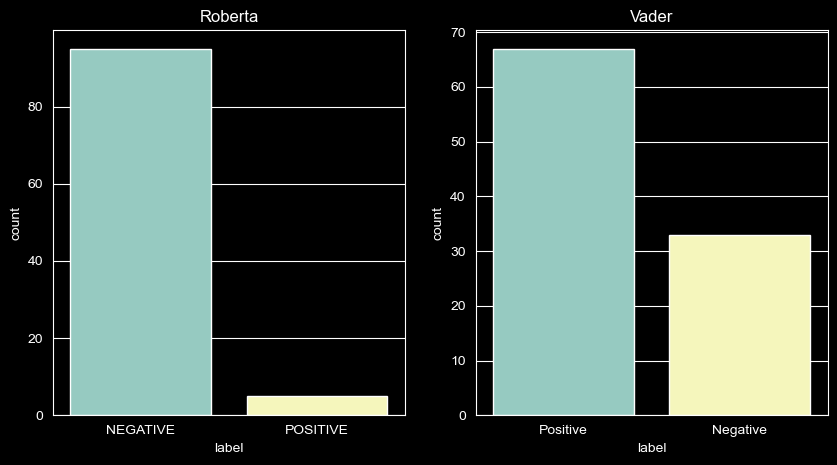

In [41]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.countplot(data=res_df,x="label",hue="label",ax=ax[0])
ax[0].set_title('Roberta')
sns.countplot(data=vad_res,x="label",hue="label",ax=ax[1])
ax[1].set_title('Vader')
plt.show()